# 03회 - 교육 플랫폼 사용자 이탈 예측

#### Q01. 라이브러리 불러오기

In [79]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### Q02. 데이터 파일 불러오기

In [80]:
edu_df = pd.read_csv('../datasets/edu_users.csv')

#### Q03. 데이터프레임 구조 확인

In [81]:
edu_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rate_math        1188 non-null   float64
 1   rate_science     1188 non-null   float64
 2   rate_english     1250 non-null   float64
 3   rate_humanities  1250 non-null   float64
 4   rate_art         1250 non-null   float64
 5   tot_time         1188 non-null   float64
 6   device           1250 non-null   str    
 7   gender           1250 non-null   str    
 8   age              1250 non-null   int64  
 9   resub_yn         1250 non-null   str    
 10  comb_yn          1250 non-null   str    
 11  othersub_yn      1250 non-null   str    
 12  leave_yn         1250 non-null   int64  
dtypes: float64(6), int64(2), str(5)
memory usage: 127.1 KB


#### Q04. 주요 과목 시청률 상관관계 분석

In [82]:
corr_list = ['rate_math', 'rate_science', 'rate_english', 'rate_humanities', 'rate_art']

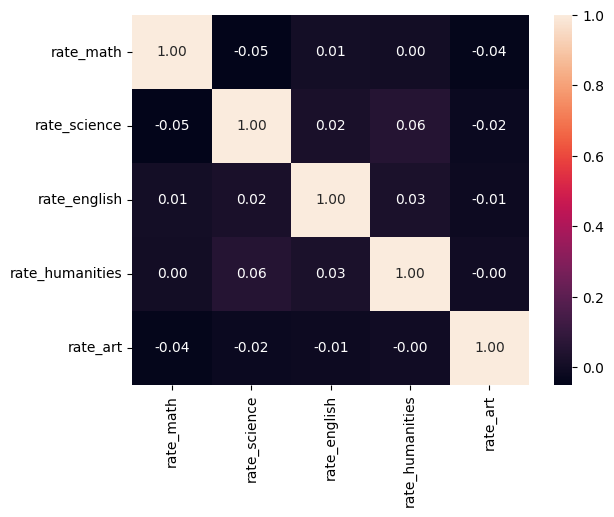

In [83]:
sns.heatmap(
    data=edu_df[corr_list].corr(),
    annot=True,     
    fmt=".2f")
답04 = 3

#### Q05. 이탈 여부에 따른 학습 시간 분포 시각화

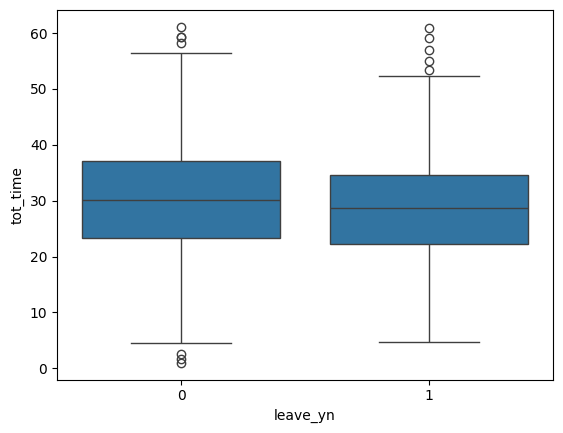

In [84]:
sns.boxplot(data=edu_df, x='leave_yn', y='tot_time')
답05 = 3

#### Q06. 이탈 여부별 주요 과목 평균 시청률 계산

In [85]:
# pivot_df = pd.pivot_table(
# 	edu_df,
# 	index='leave_yn',
# 	values=['rate_math', 'rate_science'], aggfunc='mean'
# )

pivot_df = edu_df.pivot_table(
    index='leave_yn',
    values=['rate_math', 'rate_science'], aggfunc='mean'
)

pivot_df

,rate_math,rate_science
leave_yn,,
0,0.487965,0.496375
1,0.515511,0.505424


#### Q07. 결측치 처리

In [86]:
edu_df['rate_math'] = edu_df['rate_math'].fillna(edu_df['rate_math'].mean())
edu_df['rate_science'] = edu_df['rate_science'].fillna(edu_df['rate_science'].median())
edu_df['tot_time'] = edu_df['tot_time'].fillna(edu_df['tot_time'].mode())

#### Q08. train/test 데이터 분리

In [87]:
from sklearn.model_selection import train_test_split

X = edu_df[['rate_math', 'rate_science', 'rate_english', 'tot_time']]
y = edu_df['leave_yn']

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42)

#### Q09. Feature 스케일링

In [88]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [89]:
X_train = scaler.fit_transform(X_train) 
X_test = scaler.transform(X_valid)

#### Q10. 랜덤포레스트 모델 학습

In [90]:
from sklearn.ensemble import RandomForestClassifier

In [91]:

rfc = RandomForestClassifier(
	n_estimators=150, 
	max_depth=7, 
	min_samples_split=5, 
	random_state=42
)

rfc.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

#### Q11. XGBoost 모델 학습

In [92]:
from xgboost import XGBClassifier

In [93]:
xgbc = XGBClassifier(
	n_estimators=200, 
	max_depth=5, 
	learning_rate=0.1, 
	random_state=42
)
xgbc.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

#### Q12. 모델 성능 평가

In [94]:
from sklearn.metrics import accuracy_score, f1_score

rfc_predict = rfc.predict(X_test)
xgbc_predict = xgbc.predict(X_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_valid, rfc_predict))
print("F1 Score:", f1_score(y_valid, rfc_predict))

print("XGBoost")
print("Accuracy:", accuracy_score(y_valid, xgbc_predict))
print("F1 Score:", f1_score(y_valid, xgbc_predict))

답12 = 'RF'

Random Forest
Accuracy: 0.632
F1 Score: 0.02127659574468085
XGBoost
Accuracy: 0.616
F1 Score: 0.25


#### Q13. 딥러닝 분류 모델 설계 및 학습

In [96]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
tf.random.set_seed(10)

In [99]:
model = Sequential()
model.add(Dense(64, activation='selu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dense(32, activation='selu'))
model.add(BatchNormalization())
model.add(Dense(16, activation='selu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train, y_train,
    epochs=45,
    batch_size=32
)

Epoch 1/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6830 - loss: nan  
Epoch 2/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6980 - loss: nan
Epoch 3/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6980 - loss: nan
Epoch 4/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6980 - loss: nan
Epoch 5/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6980 - loss: nan
Epoch 6/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6980 - loss: nan
Epoch 7/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6980 - loss: nan  
Epoch 8/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6980 - loss: nan
Epoch 9/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6980 - loss: nan
Epoch 10/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6980 - loss: nan
Epoch 11/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6980 - loss: nan
Epoch 12/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6980 - loss: nan
Epoch 13/45
32/32 ━━━

#### Q14. 딥러닝 모델을 이용한 시뮬레이션 예측

In [100]:
simul_data = np.array([[0.3, 0.5, 0.7, 120]])

In [111]:
deep_pre = model.predict(simul_data)
답14 = np.where(deep_pre<0, 0, 1)
print(f"답14 = {답14[0][0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
답14 = 1
